In [1]:
import pandas as pd
import pyodbc

In [2]:
server = r"KARAN\SQLEXPRESS"
database = "StreamSphereAnalytics"

connection = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


In [3]:
query = "SELECT * FROM dbo.customers"

customers = pd.read_sql(query, connection)

customers.head()

C:\Users\Karan Kapadia\AppData\Local\Temp\ipykernel_29956\4259143485.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(query, connection)


,customer_id,signup_date,age,gender,country,city,campaign_id,acquisition_channel
0,C000001,2025-05-10,56,Male,United States,New York,8,Referral
1,C000002,2025-12-31,28,Female,United States,New York,4,Instagram
2,C000003,2025-11-10,20,Female,Japan,Kyoto,7,Email
3,C000004,2023-05-02,19,Female,India,Bengaluru,10,Organic
4,C000005,2024-04-11,63,Female,United States,Los Angeles,9,Influencer


In [4]:
plans = pd.read_sql("SELECT * FROM dbo.subscription_plans", connection)

campaigns = pd.read_sql("SELECT * FROM dbo.marketing_campaigns", connection)

subscriptions = pd.read_sql("SELECT * FROM dbo.subscriptions", connection)

content = pd.read_sql("SELECT * FROM dbo.content", connection)

transactions = pd.read_sql("SELECT * FROM dbo.transactions", connection)

events = pd.read_sql("SELECT * FROM dbo.user_events", connection)

geography = pd.read_sql("SELECT * FROM dbo.geography", connection)

print("All tables loaded successfully!")

C:\Users\Karan Kapadia\AppData\Local\Temp\ipykernel_29956\3128409503.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plans = pd.read_sql("SELECT * FROM dbo.subscription_plans", connection)
C:\Users\Karan Kapadia\AppData\Local\Temp\ipykernel_29956\3128409503.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  campaigns = pd.read_sql("SELECT * FROM dbo.marketing_campaigns", connection)
C:\Users\Karan Kapadia\AppData\Local\Temp\ipykernel_29956\3128409503.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  subscriptions = p

All tables loaded successfully!


C:\Users\Karan Kapadia\AppData\Local\Temp\ipykernel_29956\3128409503.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  geography = pd.read_sql("SELECT * FROM dbo.geography", connection)


In [5]:
tables = {
    "geography": geography,
    "subscription_plans": plans,
    "marketing_campaigns": campaigns,
    "customers": customers,
    "subscriptions": subscriptions,
    "content": content,
    "transactions": transactions,
    "user_events": events
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

geography: (8, 3)
subscription_plans: (3, 5)
marketing_campaigns: (10, 7)
customers: (50000, 8)
subscriptions: (60000, 7)
content: (5000, 6)
transactions: (200000, 7)
user_events: (500000, 7)


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          50000 non-null  str   
 1   signup_date          50000 non-null  object
 2   age                  50000 non-null  int64 
 3   gender               50000 non-null  str   
 4   country              50000 non-null  str   
 5   city                 50000 non-null  str   
 6   campaign_id          50000 non-null  int64 
 7   acquisition_channel  50000 non-null  str   
dtypes: int64(2), object(1), str(5)
memory usage: 3.1+ MB


In [7]:
customers.head()

,customer_id,signup_date,age,gender,country,city,campaign_id,acquisition_channel
0,C000001,2025-05-10,56,Male,United States,New York,8,Referral
1,C000002,2025-12-31,28,Female,United States,New York,4,Instagram
2,C000003,2025-11-10,20,Female,Japan,Kyoto,7,Email
3,C000004,2023-05-02,19,Female,India,Bengaluru,10,Organic
4,C000005,2024-04-11,63,Female,United States,Los Angeles,9,Influencer


In [9]:
customers.dtypes
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

customers.dtypes

customer_id                      str
signup_date            datetime64[s]
age                            int64
gender                           str
country                          str
city                             str
campaign_id                    int64
acquisition_channel              str
dtype: object

In [10]:
customers.isnull().sum()

customer_id            0
signup_date            0
age                    0
gender                 0
country                0
city                   0
campaign_id            0
acquisition_channel    0
dtype: int64

In [ ]:
customers["customer_id"].duplicated().sum()


np.int64(0)

In [14]:
customers.duplicated().sum()

np.int64(0)

In [15]:
customers["age"].describe()

count    50000.000000
mean        41.639300
std         13.824492
min         18.000000
25%         30.000000
50%         42.000000
75%         54.000000
max         65.000000
Name: age, dtype: float64

In [16]:
customers["gender"].value_counts()

gender
Male      24041
Female    24010
Other      1949
Name: count, dtype: int64

In [17]:
customers["country"].value_counts()

country
United States     14752
India              8932
United Kingdom     6046
Canada             5090
Japan              4069
Germany            3941
Australia          3622
France             3548
Name: count, dtype: int64

In [18]:
customers["acquisition_channel"].value_counts()

acquisition_channel
Instagram     10057
Google Ads     9977
Influencer     5065
Referral       5034
Email          5007
Facebook       4993
YouTube        4981
Organic        4886
Name: count, dtype: int64

In [19]:
customers["signup_date"].dt.year.value_counts().sort_index()

signup_date
2023    16561
2024    16653
2025    16786
Name: count, dtype: int64

In [20]:
customers["city"].value_counts().head(10)

city
San Francisco    3783
New York         3689
Los Angeles      3663
Chicago          3617
Ahmedabad        2277
Delhi            2234
Mumbai           2220
Bengaluru        2201
London           2077
Manchester       2047
Name: count, dtype: int64

In [21]:
customers["campaign_id"].value_counts().sort_index()

campaign_id
1     4999
2     4978
3     5032
4     5025
5     4993
6     4981
7     5007
8     5034
9     5065
10    4886
Name: count, dtype: int64

In [22]:
subscriptions["subscription_status"].value_counts()

subscription_status
Active       39086
Cancelled    20914
Name: count, dtype: int64

In [23]:
subscriptions["plan_id"].value_counts().sort_index()

plan_id
1    24001
2    26923
3     9076
Name: count, dtype: int64

In [25]:
subscriptions[["start_date", "end_date"]].dtypes

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

subscriptions[["start_date", "end_date"]].dtypes

start_date    datetime64[s]
end_date      datetime64[s]
dtype: object

In [26]:
subscriptions["end_date"].isna().sum()

np.int64(39086)

In [27]:
subscriptions[
    (subscriptions["subscription_status"] == "Cancelled") &
    (subscriptions["end_date"].isna())
].shape[0]

0

In [28]:
subscriptions["cancellation_reason"].value_counts(dropna=False)

cancellation_reason
NaN                       39086
Too Expensive              4267
Low Engagement             4212
Switched to Competitor     4173
Not Enough Content         4158
Technical Issues           4104
Name: count, dtype: int64

In [29]:
transactions["transaction_status"].value_counts()

transaction_status
Successful    187949
Failed          8069
Refunded        3982
Name: count, dtype: int64

In [30]:
transactions["transaction_date"].dtype

dtype('O')

In [32]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["transaction_date"].dtype

transactions["amount"].describe()

count    200000.00000
mean         12.04980
std           4.06758
min           7.99000
25%           7.99000
50%          12.99000
75%          12.99000
max          19.99000
Name: amount, dtype: float64

In [33]:
transactions.isnull().sum()

transaction_id        0
subscription_id       0
customer_id           0
transaction_date      0
amount                0
transaction_status    0
payment_method        0
dtype: int64

In [34]:
transactions["transaction_id"].duplicated().sum()

np.int64(0)

In [36]:
transactions["payment_method"].value_counts()

payment_method
Credit Card       90140
Debit Card        50296
PayPal            29959
Digital Wallet    29605
Name: count, dtype: int64

In [37]:
pd.crosstab(
    transactions["payment_method"],
    transactions["transaction_status"]
)

transaction_status,Failed,Refunded,Successful
payment_method,,,
Credit Card,3663,1838,84639
Debit Card,1961,990,47345
Digital Wallet,1260,576,27769
PayPal,1185,578,28196


In [38]:
content.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   content_id        5000 non-null   str  
 1   title             5000 non-null   str  
 2   genre             5000 non-null   str  
 3   content_type      5000 non-null   str  
 4   release_year      5000 non-null   int64
 5   duration_minutes  5000 non-null   int64
dtypes: int64(2), str(4)
memory usage: 234.5 KB


In [39]:
content["genre"].value_counts()

genre
Thriller       669
Comedy         662
Action         641
Documentary    628
Drama          622
Romance        610
Sci-Fi         589
Animation      579
Name: count, dtype: int64

In [40]:
content["content_type"].value_counts()

content_type
Movie     2957
Series    2043
Name: count, dtype: int64

In [41]:
content["release_year"].describe()

count    5000.000000
mean     2018.076800
std         4.863952
min      2010.000000
25%      2014.000000
50%      2018.000000
75%      2022.000000
max      2026.000000
Name: release_year, dtype: float64

In [42]:
content["duration_minutes"].describe()

count    5000.000000
mean       94.333800
std        47.965034
min        20.000000
25%        50.000000
50%        95.000000
75%       136.000000
max       180.000000
Name: duration_minutes, dtype: float64

In [43]:
content["content_id"].duplicated().sum()

np.int64(0)

In [44]:
content.isnull().sum()

content_id          0
title               0
genre               0
content_type        0
release_year        0
duration_minutes    0
dtype: int64

In [45]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   event_id                500000 non-null  str           
 1   customer_id             500000 non-null  str           
 2   content_id              500000 non-null  str           
 3   event_timestamp         500000 non-null  datetime64[us]
 4   event_type              500000 non-null  str           
 5   watch_duration_minutes  500000 non-null  int64         
 6   device_type             500000 non-null  str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 26.7 MB


In [46]:
events["event_type"].value_counts()

event_type
Play        225189
Complete     99813
Pause        74950
Like         50134
Search       49914
Name: count, dtype: int64

In [47]:
events["device_type"].value_counts()

device_type
Mobile      174723
Smart TV    149967
Web         125177
Tablet       50133
Name: count, dtype: int64

In [48]:
events["watch_duration_minutes"].describe()

count    500000.000000
mean         51.793466
std          46.080736
min           0.000000
25%           9.000000
50%          44.000000
75%          85.000000
max         180.000000
Name: watch_duration_minutes, dtype: float64

In [49]:
events.groupby("event_type")["watch_duration_minutes"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
event_type,,,,
Complete,99813,100.218328,20,180
Like,50134,0.000000,0,0
Pause,74950,30.502508,1,60
Play,225189,60.426921,1,120
Search,49914,0.000000,0,0


In [50]:
events["event_id"].duplicated().sum()

np.int64(0)

In [51]:
events.isnull().sum()

event_id                  0
customer_id               0
content_id                0
event_timestamp           0
event_type                0
watch_duration_minutes    0
device_type               0
dtype: int64

In [53]:
events.isnull().sum()
events.duplicated().sum()

np.int64(0)

In [54]:
events["event_timestamp"].agg(["min", "max"])

min   2023-01-01 00:04:32
max   2026-12-31 23:58:12
Name: event_timestamp, dtype: datetime64[us]

In [55]:
# Geography analysis

geography.info()

print("\n--- Missing Values ---")
print(geography.isnull().sum())

print("\n--- Duplicate Rows ---")
print(geography.duplicated().sum())

print("\n--- Countries ---")
print(geography["country"].value_counts())

print("\n--- Regions ---")
print(geography["region"].value_counts())

print("\n--- Geography Data ---")
display(geography)

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   country   8 non-null      str  
 1   region    8 non-null      str  
 2   currency  8 non-null      str  
dtypes: str(3)
memory usage: 324.0 bytes

--- Missing Values ---
country     0
region      0
currency    0
dtype: int64

--- Duplicate Rows ---
0

--- Countries ---
country
Australia         1
Canada            1
France            1
Germany           1
India             1
Japan             1
United Kingdom    1
United States     1
Name: count, dtype: int64

--- Regions ---
region
Europe           3
North America    2
Asia             2
Oceania          1
Name: count, dtype: int64

--- Geography Data ---


,country,region,currency
0,Australia,Oceania,AUD
1,Canada,North America,CAD
2,France,Europe,EUR
3,Germany,Europe,EUR
4,India,Asia,INR
5,Japan,Asia,JPY
6,United Kingdom,Europe,GBP
7,United States,North America,USD


In [56]:
# Subscription Plans analysis

plans.info()

print("\n--- Missing Values ---")
print(plans.isnull().sum())

print("\n--- Duplicate Rows ---")
print(plans.duplicated().sum())

print("\n--- Duplicate Plan IDs ---")
print(plans["plan_id"].duplicated().sum())

print("\n--- Plan Distribution ---")
print(plans["plan_name"].value_counts())

print("\n--- Subscription Plans ---")
display(plans)

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   plan_id        3 non-null      int64  
 1   plan_name      3 non-null      str    
 2   monthly_price  3 non-null      float64
 3   max_devices    3 non-null      int64  
 4   video_quality  3 non-null      str    
dtypes: float64(1), int64(2), str(2)
memory usage: 252.0 bytes

--- Missing Values ---
plan_id          0
plan_name        0
monthly_price    0
max_devices      0
video_quality    0
dtype: int64

--- Duplicate Rows ---
0

--- Duplicate Plan IDs ---
0

--- Plan Distribution ---
plan_name
Basic       1
Standard    1
Premium     1
Name: count, dtype: int64

--- Subscription Plans ---


,plan_id,plan_name,monthly_price,max_devices,video_quality
0,1,Basic,7.99,1,HD
1,2,Standard,12.99,2,Full HD
2,3,Premium,19.99,4,4K


In [57]:
# Marketing Campaigns analysis

campaigns.info()

print("\n--- Missing Values ---")
print(campaigns.isnull().sum())

print("\n--- Duplicate Rows ---")
print(campaigns.duplicated().sum())

print("\n--- Duplicate Campaign IDs ---")
print(campaigns["campaign_id"].duplicated().sum())

print("\n--- Campaign Channels ---")
print(campaigns["channel"].value_counts())

print("\n--- Campaign Summary ---")
display(campaigns)

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_id    10 non-null     int64  
 1   campaign_name  10 non-null     str    
 2   channel        10 non-null     str    
 3   campaign_cost  10 non-null     float64
 4   impressions    10 non-null     int64  
 5   clicks         10 non-null     int64  
 6   conversions    10 non-null     int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 692.0 bytes

--- Missing Values ---
campaign_id      0
campaign_name    0
channel          0
campaign_cost    0
impressions      0
clicks           0
conversions      0
dtype: int64

--- Duplicate Rows ---
0

--- Duplicate Campaign IDs ---
0

--- Campaign Channels ---
channel
Google Ads    2
Instagram     2
Facebook      1
YouTube       1
Email         1
Referral      1
Influencer    1
Organic       1
Name: count, dtype: int64

--- Campaign Summary ---


,campaign_id,campaign_name,channel,campaign_cost,impressions,clicks,conversions
0,1,Google Search Q1,Google Ads,50000.0,1000000,50000,5000
1,2,Google Search Q2,Google Ads,60000.0,1200000,60000,6000
2,3,Instagram Growth Q1,Instagram,40000.0,1500000,75000,7000
3,4,Instagram Growth Q2,Instagram,45000.0,1600000,80000,7500
4,5,Facebook Awareness Q1,Facebook,35000.0,1100000,40000,3500
5,6,YouTube Launch Campaign,YouTube,55000.0,1400000,65000,5500
6,7,Email Re-engagement,Email,10000.0,300000,20000,4000
7,8,Referral Program,Referral,25000.0,800000,50000,6000
8,9,Influencer Campaign,Influencer,30000.0,900000,45000,4500
9,10,Organic Growth,Organic,5000.0,2000000,100000,10000


In [58]:
# Campaign metric validation

print("--- Negative Values ---")
print("Campaign Cost:", (campaigns["campaign_cost"] < 0).sum())
print("Impressions:", (campaigns["impressions"] < 0).sum())
print("Clicks:", (campaigns["clicks"] < 0).sum())
print("Conversions:", (campaigns["conversions"] < 0).sum())

print("\n--- Funnel Validation ---")
print("Clicks > Impressions:", (campaigns["clicks"] > campaigns["impressions"]).sum())
print("Conversions > Clicks:", (campaigns["conversions"] > campaigns["clicks"]).sum())

--- Negative Values ---
Campaign Cost: 0
Impressions: 0
Clicks: 0
Conversions: 0

--- Funnel Validation ---
Clicks > Impressions: 0
Conversions > Clicks: 0


In [59]:
# Subscription date validation

print("--- Missing Values ---")
print(subscriptions.isnull().sum())

print("\n--- Duplicate Subscription IDs ---")
print(subscriptions["subscription_id"].duplicated().sum())

print("\n--- End Date Before Start Date ---")
print((
    subscriptions["end_date"].notna() &
    (subscriptions["end_date"] < subscriptions["start_date"])
).sum())

print("\n--- Cancelled Without End Date ---")
print((
    (subscriptions["subscription_status"] == "Cancelled") &
    subscriptions["end_date"].isna()
).sum())

--- Missing Values ---
subscription_id            0
customer_id                0
plan_id                    0
start_date                 0
end_date               39086
subscription_status        0
cancellation_reason    39086
dtype: int64

--- Duplicate Subscription IDs ---
0

--- End Date Before Start Date ---
0

--- Cancelled Without End Date ---
0


In [60]:
# Transaction date validation

transaction_check = transactions.merge(
    subscriptions[["subscription_id", "start_date"]],
    on="subscription_id",
    how="left"
)

print("--- Missing Subscription Matches ---")
print(transaction_check["start_date"].isna().sum())

print("\n--- Transactions Before Subscription Start ---")
print(
    (
        transaction_check["transaction_date"] <
        transaction_check["start_date"]
    ).sum()
)

print("\n--- Transactions After Subscription Start ---")
print(
    (
        transaction_check["transaction_date"] >=
        transaction_check["start_date"]
    ).sum()
)

--- Missing Subscription Matches ---
0

--- Transactions Before Subscription Start ---
5

--- Transactions After Subscription Start ---
199995


In [61]:
# Transaction value and status validation

print("--- Missing Values ---")
print(transactions.isnull().sum())

print("\n--- Negative Amounts ---")
print((transactions["amount"] < 0).sum())

print("\n--- Transaction Statuses ---")
print(transactions["transaction_status"].value_counts())

print("\n--- Payment Methods ---")
print(transactions["payment_method"].value_counts())

print("\n--- Amount Range ---")
print(transactions["amount"].min(), "to", transactions["amount"].max())

--- Missing Values ---
transaction_id        0
subscription_id       0
customer_id           0
transaction_date      0
amount                0
transaction_status    0
payment_method        0
dtype: int64

--- Negative Amounts ---
0

--- Transaction Statuses ---
transaction_status
Successful    187949
Failed          8069
Refunded        3982
Name: count, dtype: int64

--- Payment Methods ---
payment_method
Credit Card       90140
Debit Card        50296
PayPal            29959
Digital Wallet    29605
Name: count, dtype: int64

--- Amount Range ---
7.99 to 19.99


In [62]:
# User events validation

print("--- Missing Values ---")
print(events.isnull().sum())

print("\n--- Duplicate Event IDs ---")
print(events["event_id"].duplicated().sum())

print("\n--- Duplicate Rows ---")
print(events.duplicated().sum())

print("\n--- Negative Watch Durations ---")
print((events["watch_duration_minutes"] < 0).sum())

print("\n--- Event Types ---")
print(events["event_type"].value_counts())

print("\n--- Device Types ---")
print(events["device_type"].value_counts())

--- Missing Values ---
event_id                  0
customer_id               0
content_id                0
event_timestamp           0
event_type                0
watch_duration_minutes    0
device_type               0
dtype: int64

--- Duplicate Event IDs ---
0

--- Duplicate Rows ---
0

--- Negative Watch Durations ---
0

--- Event Types ---
event_type
Play        225189
Complete     99813
Pause        74950
Like         50134
Search       49914
Name: count, dtype: int64

--- Device Types ---
device_type
Mobile      174723
Smart TV    149967
Web         125177
Tablet       50133
Name: count, dtype: int64


In [63]:
# Final data validation summary

print("========== DATA VALIDATION SUMMARY ==========\n")

for name, df in tables.items():
    print(f"{name}: {len(df):,} rows | {df.shape[1]} columns")

print("\n========== KEY DATA QUALITY CHECKS ==========\n")

print("Customers - missing values:",
      customers.isnull().sum().sum())

print("Customers - duplicate IDs:",
      customers["customer_id"].duplicated().sum())

print("Subscriptions - duplicate IDs:",
      subscriptions["subscription_id"].duplicated().sum())

print("Transactions - duplicate IDs:",
      transactions["transaction_id"].duplicated().sum())

print("Content - duplicate IDs:",
      content["content_id"].duplicated().sum())

print("Events - duplicate IDs:",
      events["event_id"].duplicated().sum())

print("\n========== KNOWN ANOMALIES ==========\n")

print(
    "Transactions before subscription start:",
    (
        transaction_check["transaction_date"] <
        transaction_check["start_date"]
    ).sum()
)

print("\nValidation completed.")

========== DATA VALIDATION SUMMARY ==========

geography: 8 rows | 3 columns
subscription_plans: 3 rows | 5 columns
marketing_campaigns: 10 rows | 7 columns
customers: 50,000 rows | 8 columns
subscriptions: 60,000 rows | 7 columns
content: 5,000 rows | 6 columns
transactions: 200,000 rows | 7 columns
user_events: 500,000 rows | 7 columns

========== KEY DATA QUALITY CHECKS ==========

Customers - missing values: 0
Customers - duplicate IDs: 0
Subscriptions - duplicate IDs: 0
Transactions - duplicate IDs: 0
Content - duplicate IDs: 0
Events - duplicate IDs: 0

========== KNOWN ANOMALIES ==========

Transactions before subscription start: 5

Validation completed.


In [64]:
# Customer distribution by country

country_customers = (
    customers["country"]
    .value_counts()
    .reset_index()
)

country_customers.columns = ["country", "customer_count"]

country_customers

,country,customer_count
0,United States,14752
1,India,8932
2,United Kingdom,6046
3,Canada,5090
4,Japan,4069
5,Germany,3941
6,Australia,3622
7,France,3548


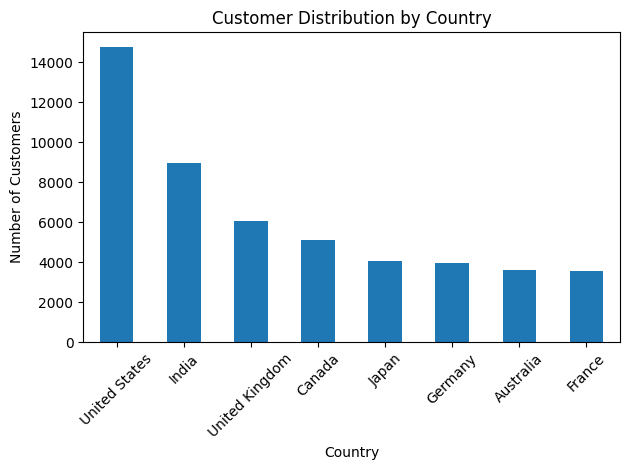

In [69]:
import matplotlib.pyplot as plt

country_customers.plot(
    x="country",
    y="customer_count",
    kind="bar",
    legend=False
)

plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [66]:
# Customer distribution by acquisition channel

channel_customers = (
    customers["acquisition_channel"]
    .value_counts()
    .reset_index()
)

channel_customers.columns = ["acquisition_channel", "customer_count"]

channel_customers

,acquisition_channel,customer_count
0,Instagram,10057
1,Google Ads,9977
2,Influencer,5065
3,Referral,5034
4,Email,5007
5,Facebook,4993
6,YouTube,4981
7,Organic,4886


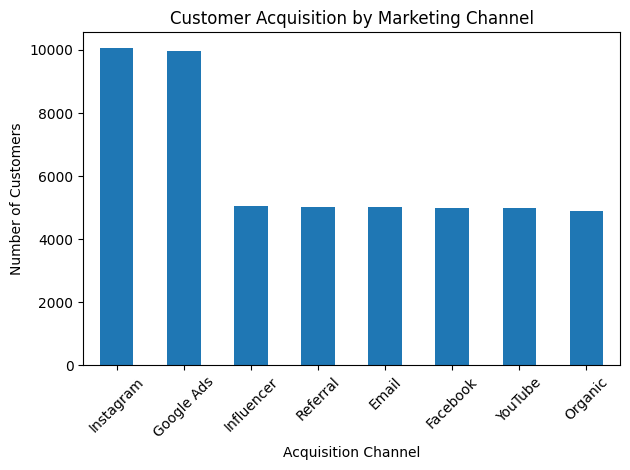

In [70]:
# Customer acquisition by channel visualization

channel_customers.plot(
    x="acquisition_channel",
    y="customer_count",
    kind="bar",
    legend=False
)

plt.title("Customer Acquisition by Marketing Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Customer acquisition by country and marketing channel

country_channel = pd.crosstab(
    customers["country"],
    customers["acquisition_channel"]
)

country_channel

acquisition_channel,Email,Facebook,Google Ads,Influencer,Instagram,Organic,Referral,YouTube
country,,,,,,,,
Australia,344,353,702,376,744,370,363,370
Canada,495,490,1045,518,997,507,534,504
France,364,362,677,371,702,335,359,378
Germany,387,365,803,403,823,395,390,375
India,892,916,1756,862,1800,913,923,870
Japan,379,384,833,428,854,370,422,399
United Kingdom,631,661,1210,610,1178,586,596,574
United States,1515,1462,2951,1497,2959,1410,1447,1511


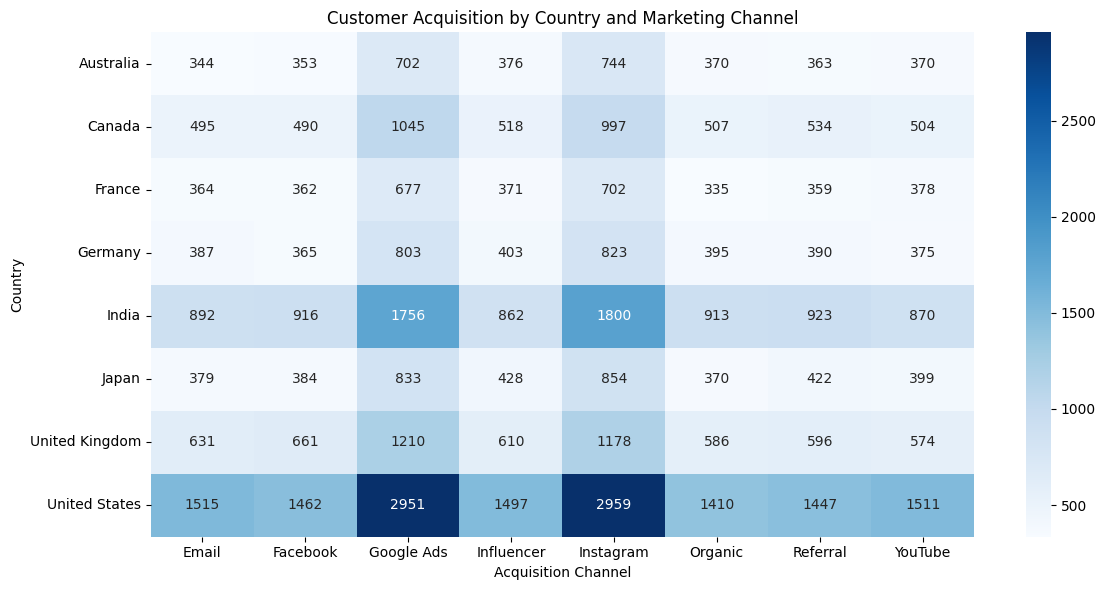

In [72]:
# Customer acquisition by country and marketing channel - heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    country_channel,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Customer Acquisition by Country and Marketing Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [73]:
# Subscription plan distribution

plan_distribution = (
    subscriptions["plan_id"]
    .value_counts()
    .reset_index()
)

plan_distribution.columns = ["plan_id", "subscription_count"]

plan_distribution = plan_distribution.merge(
    plans[["plan_id", "plan_name"]],
    on="plan_id",
    how="left"
)

plan_distribution = plan_distribution[
    ["plan_id", "plan_name", "subscription_count"]
].sort_values(
    "subscription_count",
    ascending=False
)

plan_distribution

,plan_id,plan_name,subscription_count
0,2,Standard,26923
1,1,Basic,24001
2,3,Premium,9076


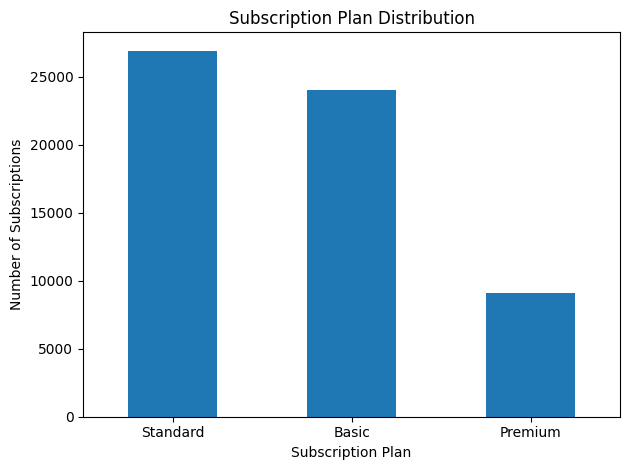

In [74]:
# Subscription plan distribution visualization

plan_distribution.plot(
    x="plan_name",
    y="subscription_count",
    kind="bar",
    legend=False
)

plt.title("Subscription Plan Distribution")
plt.xlabel("Subscription Plan")
plt.ylabel("Number of Subscriptions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
# Active vs cancelled subscriptions

subscription_status = (
    subscriptions["subscription_status"]
    .value_counts()
    .reset_index()
)

subscription_status.columns = ["subscription_status", "subscription_count"]

subscription_status

,subscription_status,subscription_count
0,Active,39086
1,Cancelled,20914


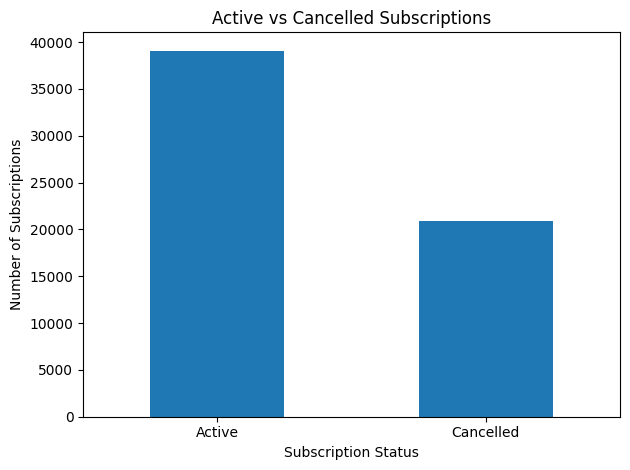

In [76]:
# Active vs cancelled subscriptions visualization

subscription_status.plot(
    x="subscription_status",
    y="subscription_count",
    kind="bar",
    legend=False
)

plt.title("Active vs Cancelled Subscriptions")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Subscriptions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
# Subscription status by plan

status_by_plan = pd.crosstab(
    subscriptions["plan_id"],
    subscriptions["subscription_status"]
)

status_by_plan = status_by_plan.merge(
    plans[["plan_id", "plan_name"]],
    on="plan_id",
    how="left"
)

status_by_plan = status_by_plan[
    ["plan_id", "plan_name", "Active", "Cancelled"]
]

status_by_plan

,plan_id,plan_name,Active,Cancelled
0,1,Basic,15543,8458
1,2,Standard,17544,9379
2,3,Premium,5999,3077


In [78]:
# Cancellation rate by subscription plan

cancellation_by_plan = (
    subscriptions
    .groupby(["plan_id", "subscription_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

cancellation_by_plan = cancellation_by_plan.merge(
    plans[["plan_id", "plan_name"]],
    on="plan_id",
    how="left"
)

cancellation_by_plan["cancellation_rate"] = (
    cancellation_by_plan["Cancelled"]
    / (
        cancellation_by_plan["Active"]
        + cancellation_by_plan["Cancelled"]
    )
    * 100
)

cancellation_by_plan = cancellation_by_plan[
    ["plan_id", "plan_name", "Active", "Cancelled", "cancellation_rate"]
].sort_values(
    "cancellation_rate",
    ascending=False
)

cancellation_by_plan

,plan_id,plan_name,Active,Cancelled,cancellation_rate
0,1,Basic,15543,8458,35.240198
1,2,Standard,17544,9379,34.836385
2,3,Premium,5999,3077,33.902600


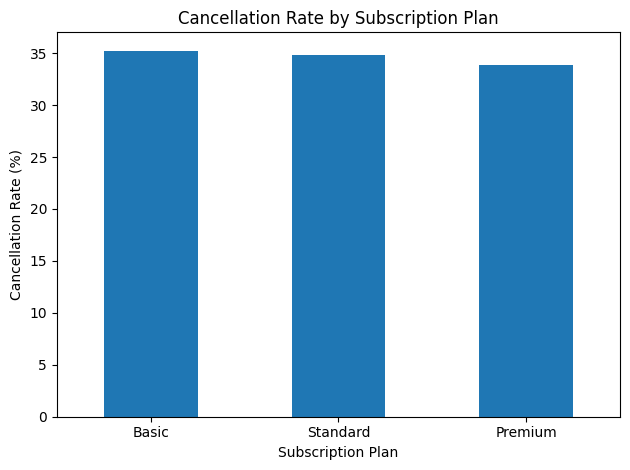

In [79]:
# Cancellation rate by subscription plan visualization

cancellation_by_plan.plot(
    x="plan_name",
    y="cancellation_rate",
    kind="bar",
    legend=False
)

plt.title("Cancellation Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [80]:
# Cancellation reasons analysis

cancellation_reasons = (
    subscriptions.loc[
        subscriptions["subscription_status"] == "Cancelled",
        "cancellation_reason"
    ]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = [
    "cancellation_reason",
    "cancelled_count"
]

cancellation_reasons

,cancellation_reason,cancelled_count
0,Too Expensive,4267
1,Low Engagement,4212
2,Switched to Competitor,4173
3,Not Enough Content,4158
4,Technical Issues,4104


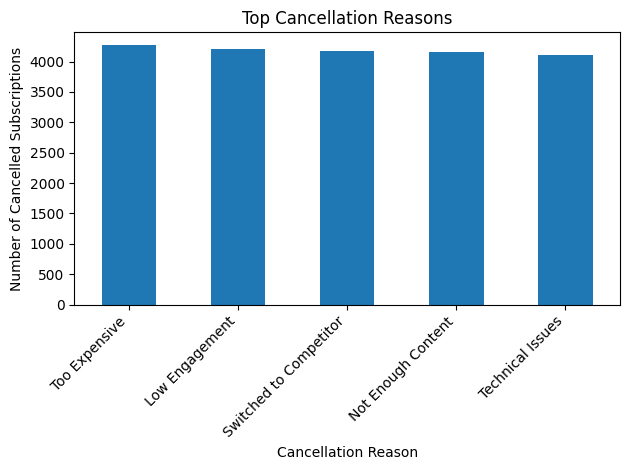

In [81]:
# Cancellation reasons visualization

cancellation_reasons.plot(
    x="cancellation_reason",
    y="cancelled_count",
    kind="bar",
    legend=False
)

plt.title("Top Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancelled Subscriptions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [82]:
# Cancellation reasons by subscription plan

cancellation_reason_by_plan = pd.crosstab(
    subscriptions.loc[
        subscriptions["subscription_status"] == "Cancelled",
        "plan_id"
    ],
    subscriptions.loc[
        subscriptions["subscription_status"] == "Cancelled",
        "cancellation_reason"
    ]
)

cancellation_reason_by_plan = cancellation_reason_by_plan.merge(
    plans[["plan_id", "plan_name"]],
    on="plan_id",
    how="left"
)

cancellation_reason_by_plan = cancellation_reason_by_plan[
    ["plan_id", "plan_name"] +
    [
        col for col in cancellation_reason_by_plan.columns
        if col not in ["plan_id", "plan_name"]
    ]
]

cancellation_reason_by_plan

,plan_id,plan_name,Low Engagement,Not Enough Content,Switched to Competitor,Technical Issues,Too Expensive
0,1,Basic,1737,1708,1696,1671,1646
1,2,Standard,1872,1884,1846,1823,1954
2,3,Premium,603,566,631,610,667


In [83]:
# Cancellation reasons analysis

cancellation_reasons = (
    subscriptions.loc[
        subscriptions["subscription_status"] == "Cancelled",
        "cancellation_reason"
    ]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = [
    "cancellation_reason",
    "cancelled_count"
]

cancellation_reasons

,cancellation_reason,cancelled_count
0,Too Expensive,4267
1,Low Engagement,4212
2,Switched to Competitor,4173
3,Not Enough Content,4158
4,Technical Issues,4104


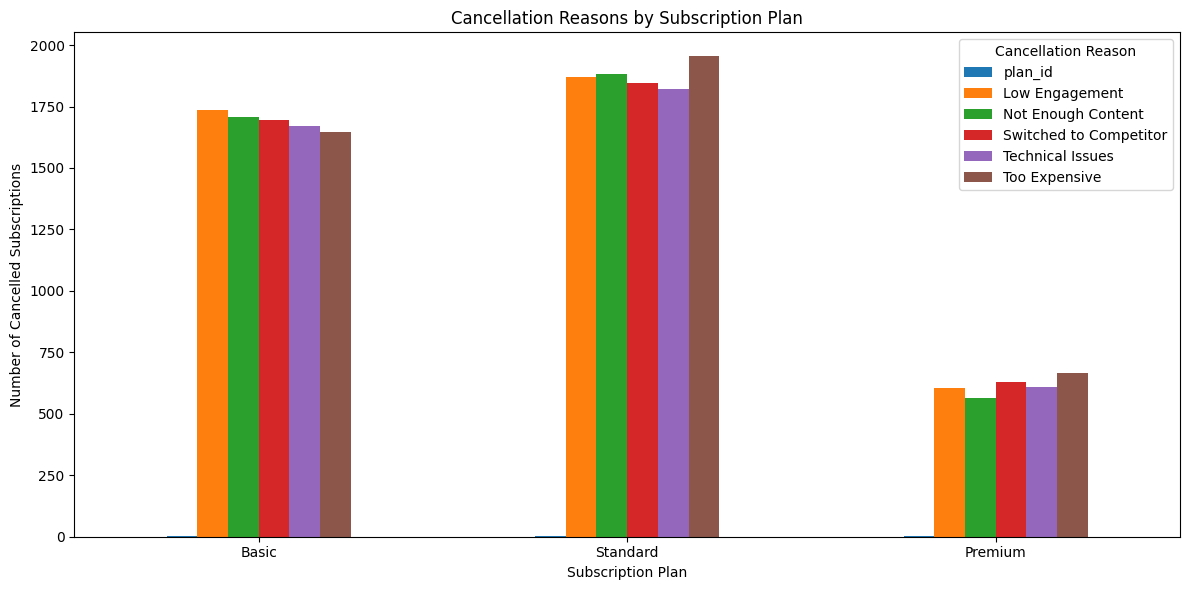

In [84]:
# Cancellation reasons by subscription plan visualization

cancellation_reason_by_plan.set_index("plan_name").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cancellation Reasons by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Number of Cancelled Subscriptions")
plt.xticks(rotation=0)
plt.legend(title="Cancellation Reason")
plt.tight_layout()
plt.show()

In [85]:

# Total successful revenue

total_revenue = transactions.loc[
    transactions["transaction_status"] == "Successful",
    "amount"
].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,264,919.51


In [86]:
# Average successful transaction value

successful_transactions = transactions[
    transactions["transaction_status"] == "Successful"
]

average_transaction_value = successful_transactions["amount"].mean()

print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

Average Transaction Value: $12.05


In [87]:
# Revenue by subscription plan

revenue_by_plan = (
    successful_transactions
    .merge(
        subscriptions[["subscription_id", "plan_id"]],
        on="subscription_id",
        how="left"
    )
    .merge(
        plans[["plan_id", "plan_name"]],
        on="plan_id",
        how="left"
    )
    .groupby("plan_name", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
)

revenue_by_plan

,plan_name,total_revenue
2,Standard,1093796.97
0,Basic,601087.70
1,Premium,570034.84


In [88]:
# Revenue by country

revenue_by_country = (
    successful_transactions
    .merge(
        customers[["customer_id", "country"]],
        on="customer_id",
        how="left"
    )
    .groupby("country", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
)

revenue_by_country

,country,total_revenue
7,United States,663043.58
4,India,415982.56
6,United Kingdom,272744.45
1,Canada,225977.30
3,Germany,183810.64
5,Japan,179374.31
0,Australia,162769.37
2,France,161217.30


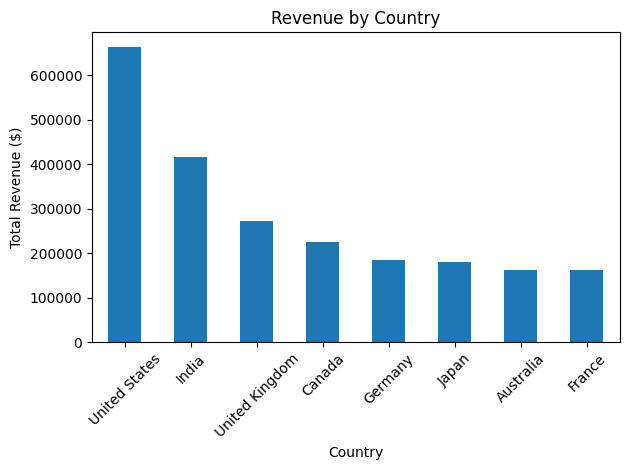

In [89]:
# Revenue by country visualization

revenue_by_country.plot(
    x="country",
    y="total_revenue",
    kind="bar",
    legend=False
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
# Monthly revenue trend

monthly_revenue = (
    successful_transactions
    .assign(
        month=successful_transactions["transaction_date"].dt.to_period("M")
    )
    .groupby("month", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_revenue"})
)

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

monthly_revenue

,month,total_revenue
0,2023-01,1718.54
1,2023-02,4712.01
2,2023-03,8285.30
3,2023-04,11753.23
4,2023-05,15138.11
...,...,...
56,2027-09,7393.75
57,2027-10,4870.90
58,2027-11,2849.59
59,2027-12,952.24


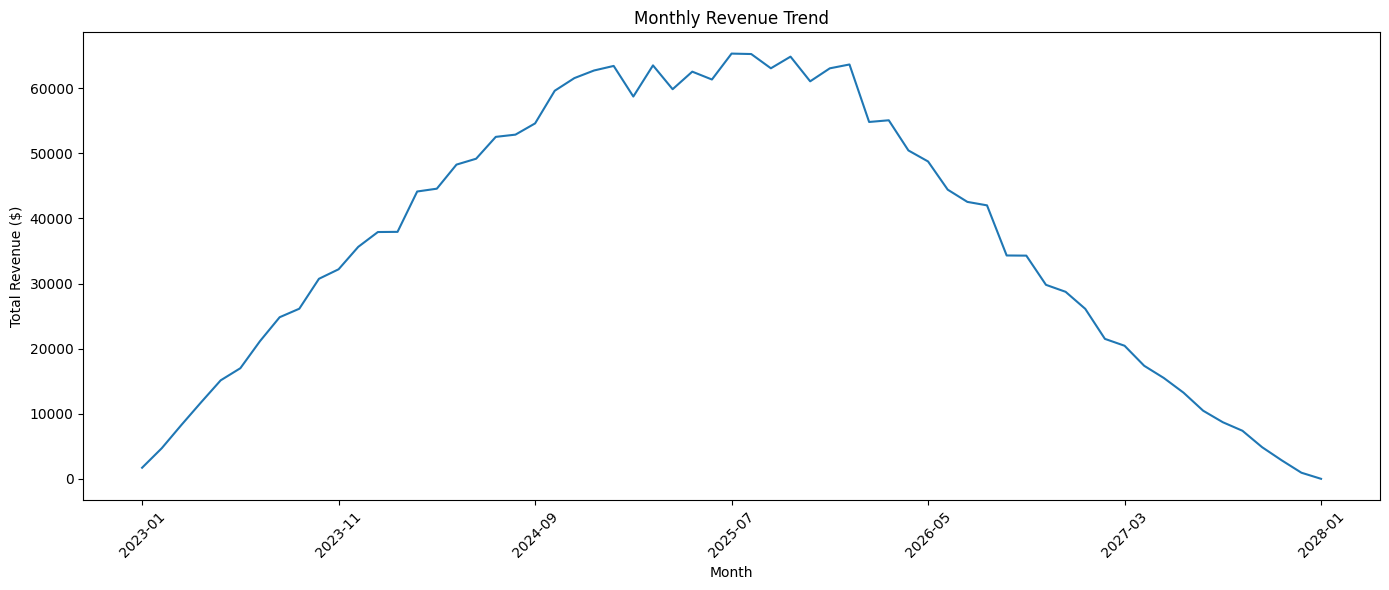

In [91]:
# Monthly revenue trend visualization

monthly_revenue.plot(
    x="month",
    y="total_revenue",
    kind="line",
    figsize=(14, 6),
    legend=False
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
# Most popular content by number of user events

popular_content = (
    events
    .groupby("content_id")
    .size()
    .reset_index(name="event_count")
    .merge(
        content[["content_id", "title", "genre", "content_type"]],
        on="content_id",
        how="left"
    )
    .sort_values("event_count", ascending=False)
)

popular_content.head(10)

,content_id,event_count,title,genre,content_type
3870,CT03871,139,Save Cause,Documentary,Movie
4138,CT04139,137,Reality Fish,Sci-Fi,Movie
49,CT00050,136,Maybe Seven,Animation,Series
787,CT00788,136,Loss Go,Drama,Movie
4036,CT04037,133,True Seat,Sci-Fi,Movie
1325,CT01326,133,Six Kid,Thriller,Movie
678,CT00679,133,Stop Project,Animation,Movie
4076,CT04077,132,Rock Would,Drama,Series
3251,CT03252,132,Involve School,Animation,Movie
4060,CT04061,132,Wrong Make,Comedy,Series


In [93]:
# Most active customers by number of user events

active_customers = (
    events
    .groupby("customer_id")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

active_customers.head(10)

,customer_id,event_count
36464,C036465,26
42363,C042364,25
11063,C011064,24
420,C000421,24
36357,C036358,24
16220,C016221,24
38731,C038732,24
43105,C043106,24
25055,C025056,24
40661,C040662,23


In [94]:
# Most common user event types

event_type_distribution = (
    events["event_type"]
    .value_counts()
    .reset_index()
)

event_type_distribution.columns = [
    "event_type",
    "event_count"
]

event_type_distribution

,event_type,event_count
0,Play,225189
1,Complete,99813
2,Pause,74950
3,Like,50134
4,Search,49914


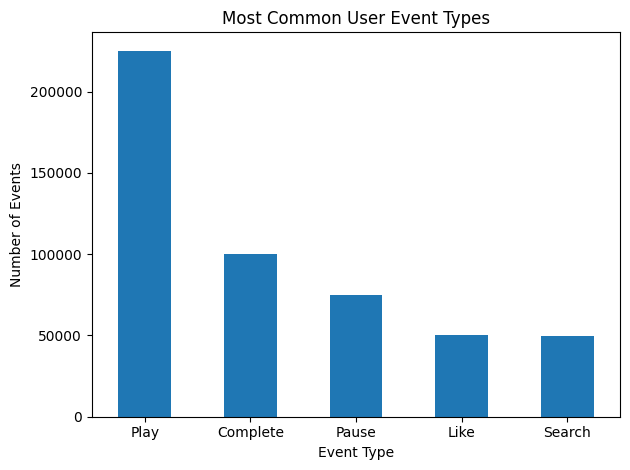

In [95]:
# User event type distribution visualization

event_type_distribution.plot(
    x="event_type",
    y="event_count",
    kind="bar",
    legend=False
)

plt.title("Most Common User Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [96]:
# Content with highest average watch duration

content_watch_duration = (
    events
    .groupby("content_id")["watch_duration_minutes"]
    .mean()
    .reset_index(name="average_watch_duration")
    .merge(
        content[["content_id", "title", "genre", "content_type"]],
        on="content_id",
        how="left"
    )
    .sort_values("average_watch_duration", ascending=False)
)

content_watch_duration.head(10)

,content_id,average_watch_duration,title,genre,content_type
2707,CT02708,71.242424,Blue Mission,Action,Movie
3104,CT03105,70.542857,Word For,Romance,Series
2925,CT02926,68.647059,Clearly Tree,Thriller,Series
83,CT00084,68.371134,Determine Race,Sci-Fi,Movie
784,CT00785,67.780220,Manage Employee,Action,Movie
2637,CT02638,66.494624,Race Simple,Action,Movie
1276,CT01277,66.413043,Sister Explain,Documentary,Movie
3165,CT03166,66.382716,Recently Base,Action,Movie
4602,CT04603,66.183673,Phone Community,Documentary,Movie
2246,CT02247,66.022989,Matter Evening,Sci-Fi,Movie


In [97]:
# Content with highest average watch duration

content_watch_duration = (
    events
    .groupby("content_id")["watch_duration_minutes"]
    .mean()
    .reset_index(name="average_watch_duration")
    .merge(
        content[["content_id", "title", "genre", "content_type"]],
        on="content_id",
        how="left"
    )
    .sort_values("average_watch_duration", ascending=False)
)

content_watch_duration.head(10)

,content_id,average_watch_duration,title,genre,content_type
2707,CT02708,71.242424,Blue Mission,Action,Movie
3104,CT03105,70.542857,Word For,Romance,Series
2925,CT02926,68.647059,Clearly Tree,Thriller,Series
83,CT00084,68.371134,Determine Race,Sci-Fi,Movie
784,CT00785,67.780220,Manage Employee,Action,Movie
2637,CT02638,66.494624,Race Simple,Action,Movie
1276,CT01277,66.413043,Sister Explain,Documentary,Movie
3165,CT03166,66.382716,Recently Base,Action,Movie
4602,CT04603,66.183673,Phone Community,Documentary,Movie
2246,CT02247,66.022989,Matter Evening,Sci-Fi,Movie


In [98]:
# User engagement by country

engagement_by_country = (
    events
    .merge(
        customers[["customer_id", "country"]],
        on="customer_id",
        how="left"
    )
    .groupby("country")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

engagement_by_country

,country,event_count
7,United States,147968
4,India,88944
6,United Kingdom,60638
1,Canada,50880
5,Japan,40415
3,Germany,39156
0,Australia,36385
2,France,35614


In [99]:
# Monthly customer acquisition trend

monthly_acquisition = (
    customers
    .assign(
        month=customers["signup_date"].dt.to_period("M")
    )
    .groupby("month")
    .size()
    .reset_index(name="new_customers")
)

monthly_acquisition["month"] = monthly_acquisition["month"].astype(str)

monthly_acquisition

,month,new_customers
0,2023-01,1443
1,2023-02,1201
2,2023-03,1407
3,2023-04,1399
4,2023-05,1397
5,2023-06,1335
6,2023-07,1394
7,2023-08,1454
8,2023-09,1404
9,2023-10,1343


In [100]:
# Overall churn rate

total_subscriptions = len(subscriptions)

cancelled_subscriptions = (
    subscriptions["subscription_status"] == "Cancelled"
).sum()

churn_rate = (
    cancelled_subscriptions
    / total_subscriptions
    * 100
)

print(f"Total Subscriptions: {total_subscriptions:,}")
print(f"Cancelled Subscriptions: {cancelled_subscriptions:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Subscriptions: 60,000
Cancelled Subscriptions: 20,914
Overall Churn Rate: 34.86%


In [101]:
# Marketing campaign conversion rate

campaign_conversion = campaigns.copy()

campaign_conversion["conversion_rate"] = (
    campaign_conversion["conversions"]
    / campaign_conversion["clicks"]
    * 100
)

campaign_conversion = campaign_conversion[
    [
        "campaign_id",
        "campaign_name",
        "channel",
        "campaign_cost",
        "impressions",
        "clicks",
        "conversions",
        "conversion_rate"
    ]
].sort_values(
    "conversion_rate",
    ascending=False
)

campaign_conversion

,campaign_id,campaign_name,channel,campaign_cost,impressions,clicks,conversions,conversion_rate
6,7,Email Re-engagement,Email,10000.0,300000,20000,4000,20.000000
7,8,Referral Program,Referral,25000.0,800000,50000,6000,12.000000
1,2,Google Search Q2,Google Ads,60000.0,1200000,60000,6000,10.000000
0,1,Google Search Q1,Google Ads,50000.0,1000000,50000,5000,10.000000
9,10,Organic Growth,Organic,5000.0,2000000,100000,10000,10.000000
8,9,Influencer Campaign,Influencer,30000.0,900000,45000,4500,10.000000
3,4,Instagram Growth Q2,Instagram,45000.0,1600000,80000,7500,9.375000
2,3,Instagram Growth Q1,Instagram,40000.0,1500000,75000,7000,9.333333
4,5,Facebook Awareness Q1,Facebook,35000.0,1100000,40000,3500,8.750000
5,6,YouTube Launch Campaign,YouTube,55000.0,1400000,65000,5500,8.461538


In [102]:
# Customer Lifetime Value (CLV)

customer_clv = (
    successful_transactions
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="customer_lifetime_value")
    .sort_values(
        "customer_lifetime_value",
        ascending=False
    )
)

customer_clv.head(10)

,customer_id,customer_lifetime_value
5419,C007942,476.71
27542,C040223,414.73
19464,C028433,379.81
236,C000352,378.75
11055,C016103,374.76
18338,C026760,374.75
7264,C010643,370.79
3567,C005228,369.78
23726,C034671,367.68
14339,C020930,363.79


In [103]:
# Customer revenue ranking

customer_revenue_ranking = (
    successful_transactions
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="total_revenue")
)

customer_revenue_ranking["revenue_rank"] = (
    customer_revenue_ranking["total_revenue"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

customer_revenue_ranking = customer_revenue_ranking.sort_values(
    "revenue_rank"
)

customer_revenue_ranking.head(10)

,customer_id,total_revenue,revenue_rank
5419,C007942,476.71,1
27542,C040223,414.73,2
19464,C028433,379.81,3
236,C000352,378.75,4
11055,C016103,374.76,5
18338,C026760,374.75,6
7264,C010643,370.79,7
3567,C005228,369.78,8
23726,C034671,367.68,9
14339,C020930,363.79,10


In [104]:
# Customer revenue ranking

customer_revenue_ranking = (
    successful_transactions
    .groupby("customer_id")["amount"]
    .sum()
    .reset_index(name="total_revenue")
)

customer_revenue_ranking["revenue_rank"] = (
    customer_revenue_ranking["total_revenue"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

customer_revenue_ranking = customer_revenue_ranking.sort_values(
    "revenue_rank"
)

customer_revenue_ranking.head(10)

,customer_id,total_revenue,revenue_rank
5419,C007942,476.71,1
27542,C040223,414.73,2
19464,C028433,379.81,3
236,C000352,378.75,4
11055,C016103,374.76,5
18338,C026760,374.75,6
7264,C010643,370.79,7
3567,C005228,369.78,8
23726,C034671,367.68,9
14339,C020930,363.79,10


In [105]:
# Key business KPIs

total_customers = len(customers)
total_subscriptions = len(subscriptions)
active_subscriptions = (
    subscriptions["subscription_status"] == "Active"
).sum()
cancelled_subscriptions = (
    subscriptions["subscription_status"] == "Cancelled"
).sum()

churn_rate = (
    cancelled_subscriptions / total_subscriptions
) * 100

successful_revenue = successful_transactions["amount"].sum()
average_transaction = successful_transactions["amount"].mean()

print("========== STREAMSPHERE KEY KPIs ==========")
print(f"Total Customers: {total_customers:,}")
print(f"Total Subscriptions: {total_subscriptions:,}")
print(f"Active Subscriptions: {active_subscriptions:,}")
print(f"Cancelled Subscriptions: {cancelled_subscriptions:,}")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Successful Revenue: ${successful_revenue:,.2f}")
print(f"Average Transaction Value: ${average_transaction:,.2f}")

========== STREAMSPHERE KEY KPIs ==========
Total Customers: 50,000
Total Subscriptions: 60,000
Active Subscriptions: 39,086
Cancelled Subscriptions: 20,914
Churn Rate: 34.86%
Successful Revenue: $2,264,919.51
Average Transaction Value: $12.05


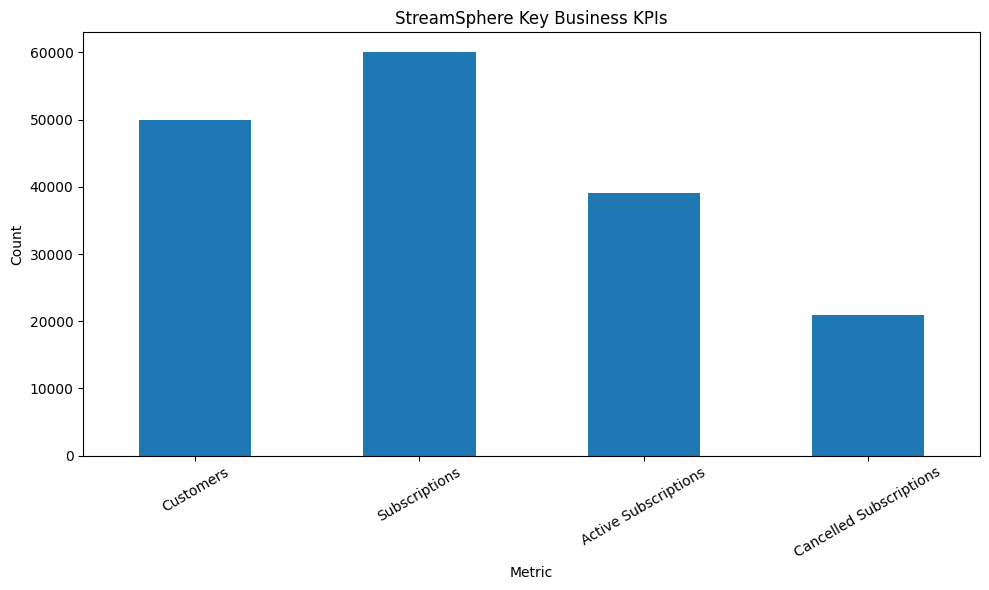

In [106]:
# KPI visualization

kpi_data = pd.DataFrame({
    "metric": [
        "Customers",
        "Subscriptions",
        "Active Subscriptions",
        "Cancelled Subscriptions"
    ],
    "value": [
        total_customers,
        total_subscriptions,
        active_subscriptions,
        cancelled_subscriptions
    ]
})

kpi_data.plot(
    x="metric",
    y="value",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("StreamSphere Key Business KPIs")
plt.xlabel("Metric")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

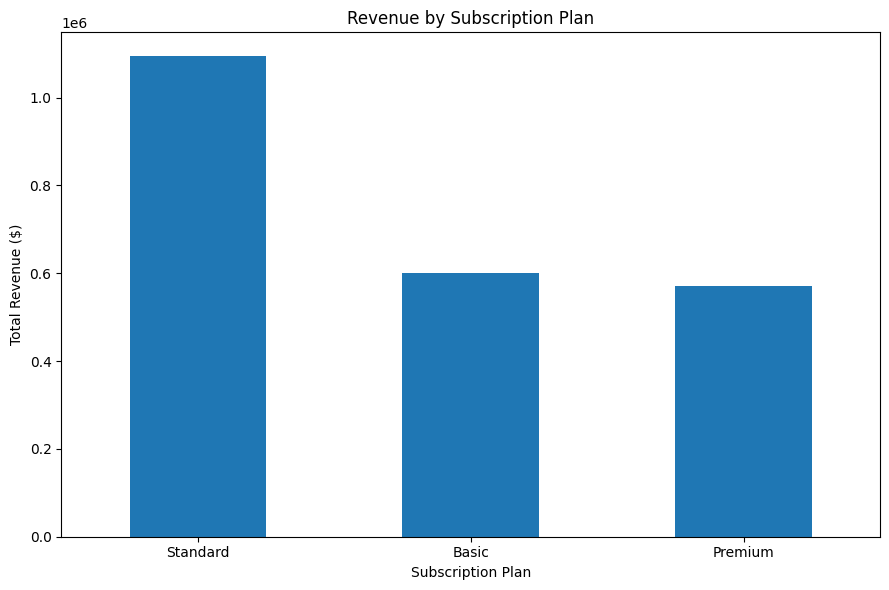

In [107]:
# Revenue by subscription plan visualization

revenue_by_plan.plot(
    x="plan_name",
    y="total_revenue",
    kind="bar",
    legend=False,
    figsize=(9, 6)
)

plt.title("Revenue by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

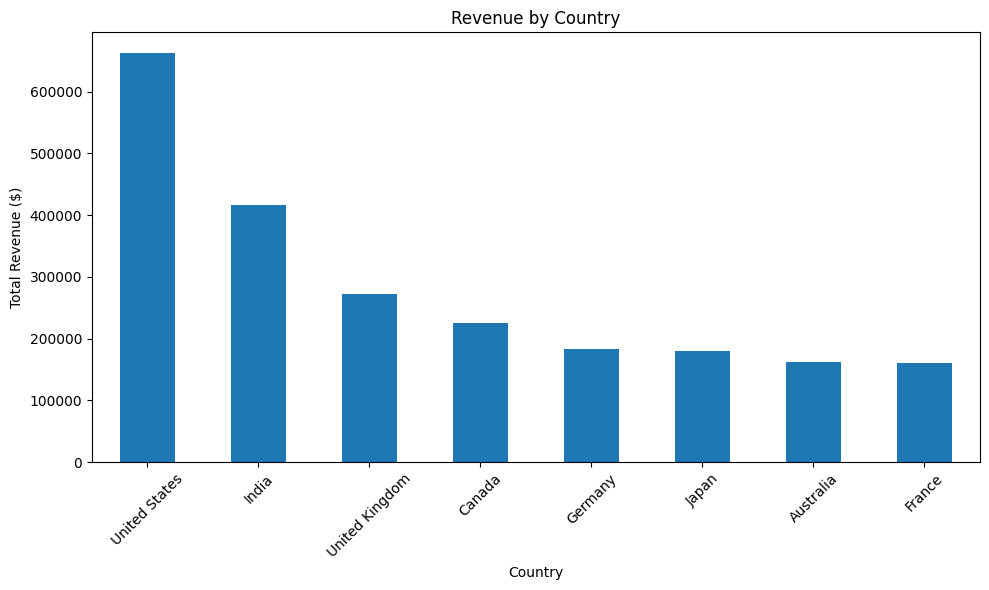

In [108]:
# Revenue by country visualization

revenue_by_country.plot(
    x="country",
    y="total_revenue",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

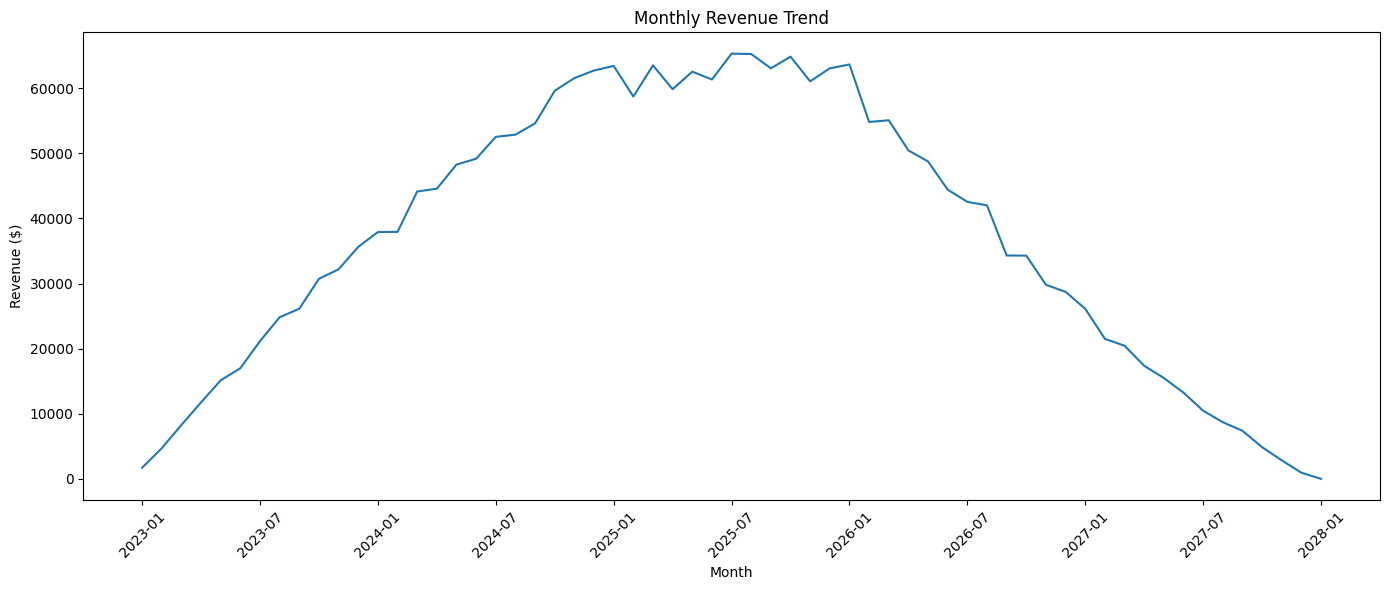

In [109]:
# Monthly revenue trend visualization

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(
    range(0, len(monthly_revenue), 6),
    monthly_revenue["month"].iloc[::6],
    rotation=45
)

plt.tight_layout()
plt.show()

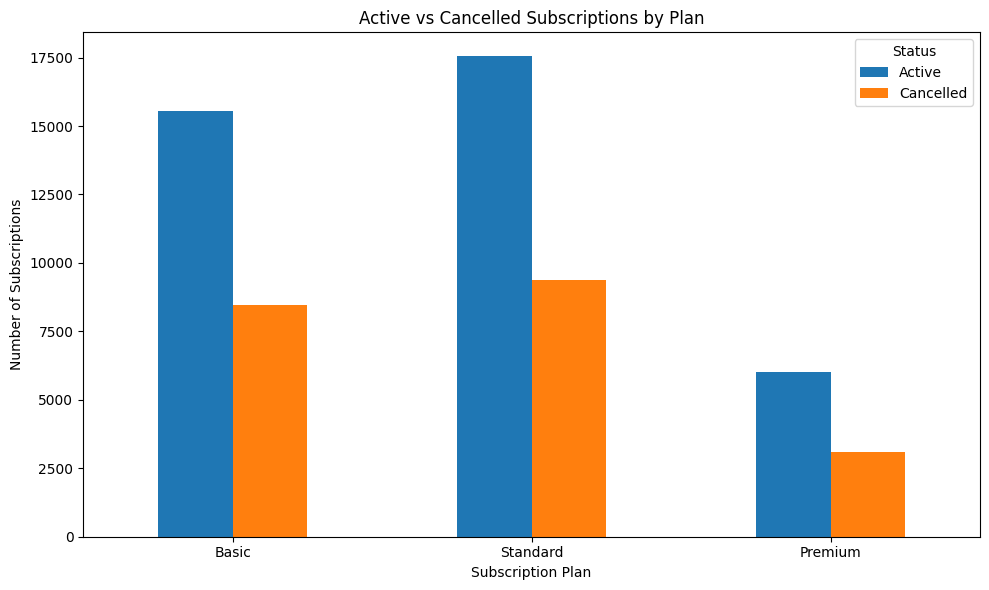

In [110]:
# Active vs cancelled subscriptions by plan

status_by_plan_plot = status_by_plan.set_index("plan_name")[
    ["Active", "Cancelled"]
]

status_by_plan_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Active vs Cancelled Subscriptions by Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Number of Subscriptions")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [ ]:
# Cancellation reasons analysis

cancellation_reasons = (
    subscriptions.loc[
        subscriptions["subscription_status"] == "Cancelled",
        "cancellation_reason"
    ]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = [
    "cancellation_reason",
    "cancelled_count"
]

cancellation_reasons

,cancellation_reason,cancelled_count
0,Too Expensive,4267
1,Low Engagement,4212
2,Switched to Competitor,4173
3,Not Enough Content,4158
4,Technical Issues,4104


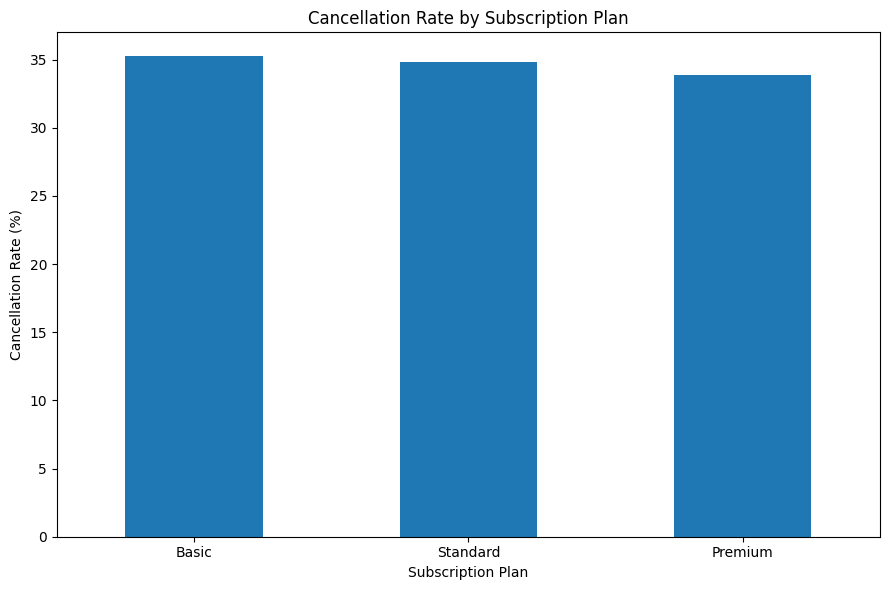

In [111]:
# Cancellation rate by plan visualization

cancellation_by_plan.plot(
    x="plan_name",
    y="cancellation_rate",
    kind="bar",
    legend=False,
    figsize=(9, 6)
)

plt.title("Cancellation Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

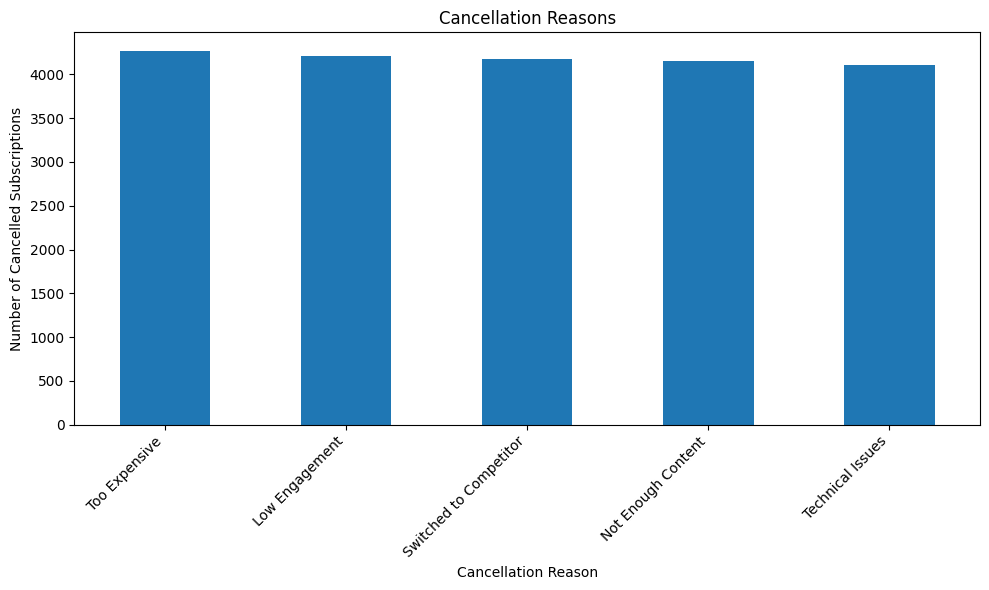

In [112]:
# Cancellation reasons visualization

cancellation_reasons.plot(
    x="cancellation_reason",
    y="cancelled_count",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancelled Subscriptions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

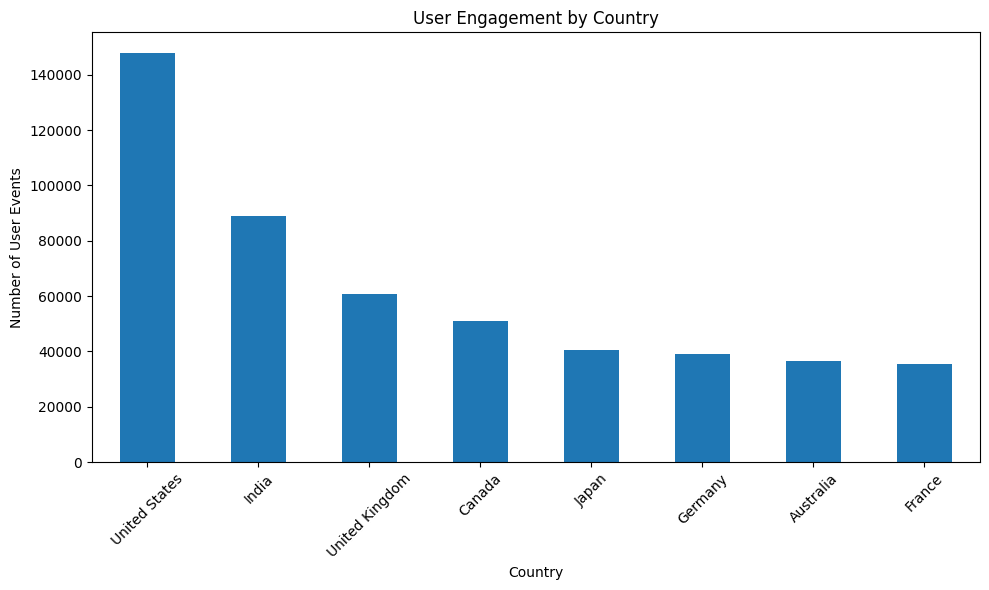

In [113]:
# User engagement by country visualization

engagement_by_country.plot(
    x="country",
    y="event_count",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("User Engagement by Country")
plt.xlabel("Country")
plt.ylabel("Number of User Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

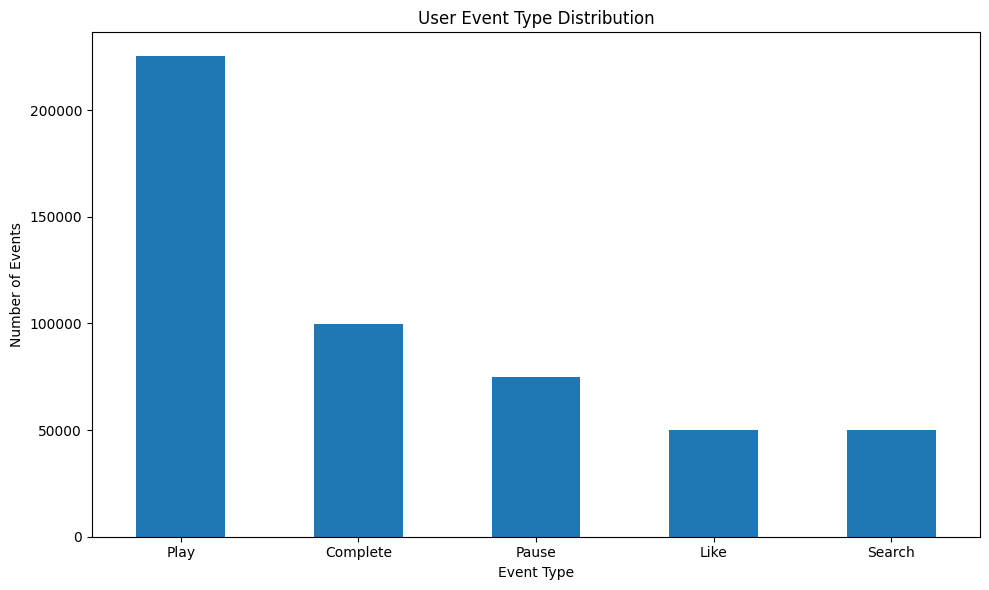

In [114]:
# User event type distribution visualization

event_type_distribution.plot(
    x="event_type",
    y="event_count",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("User Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

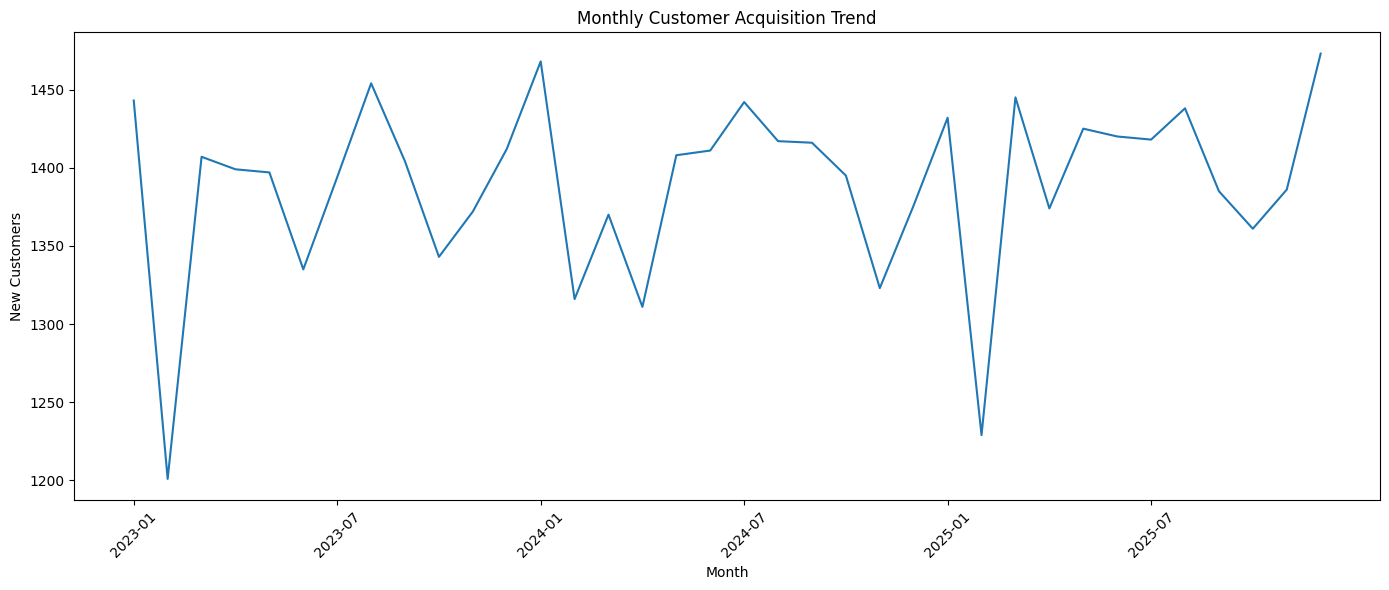

In [116]:
# Monthly customer acquisition trend visualization

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_acquisition["month"],
    monthly_acquisition["new_customers"]
)

plt.title("Monthly Customer Acquisition Trend")
plt.xlabel("Month")
plt.ylabel("New Customers")
plt.xticks(
    range(0, len(monthly_acquisition), 6),
    monthly_acquisition["month"].iloc[::6],
    rotation=45
)

plt.tight_layout()
plt.show()

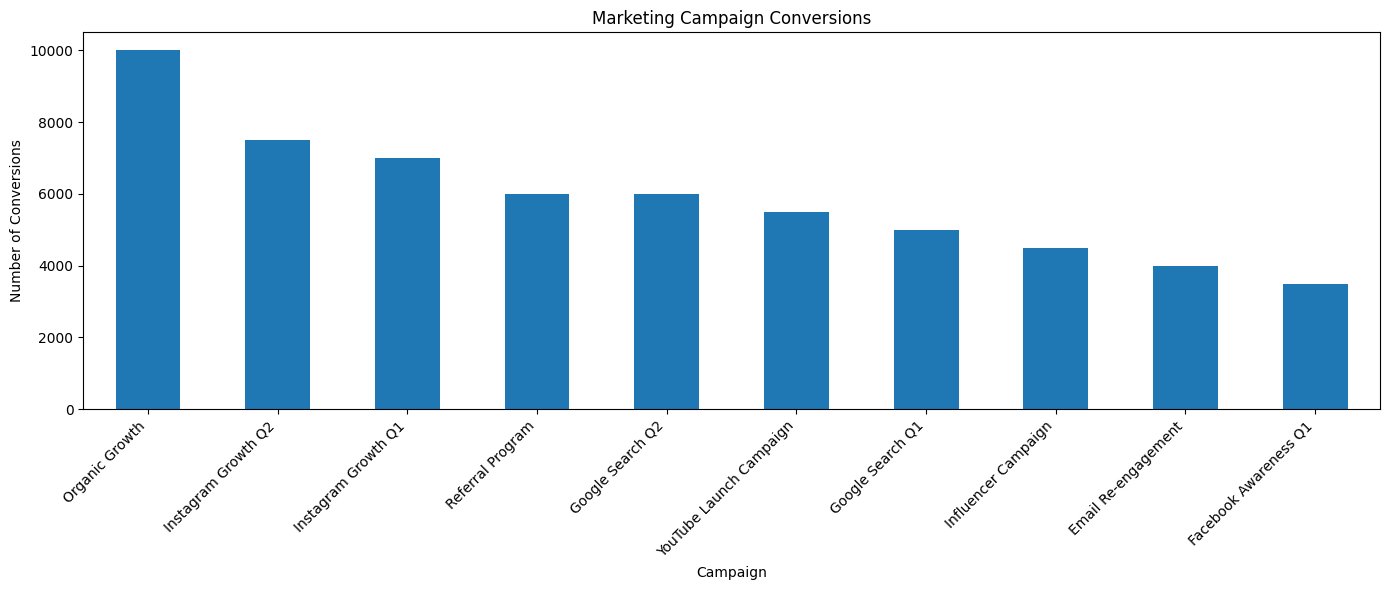

In [117]:
# Marketing campaign conversion visualization

campaign_conversion.sort_values(
    "conversions",
    ascending=False
).plot(
    x="campaign_name",
    y="conversions",
    kind="bar",
    legend=False,
    figsize=(14, 6)
)

plt.title("Marketing Campaign Conversions")
plt.xlabel("Campaign")
plt.ylabel("Number of Conversions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


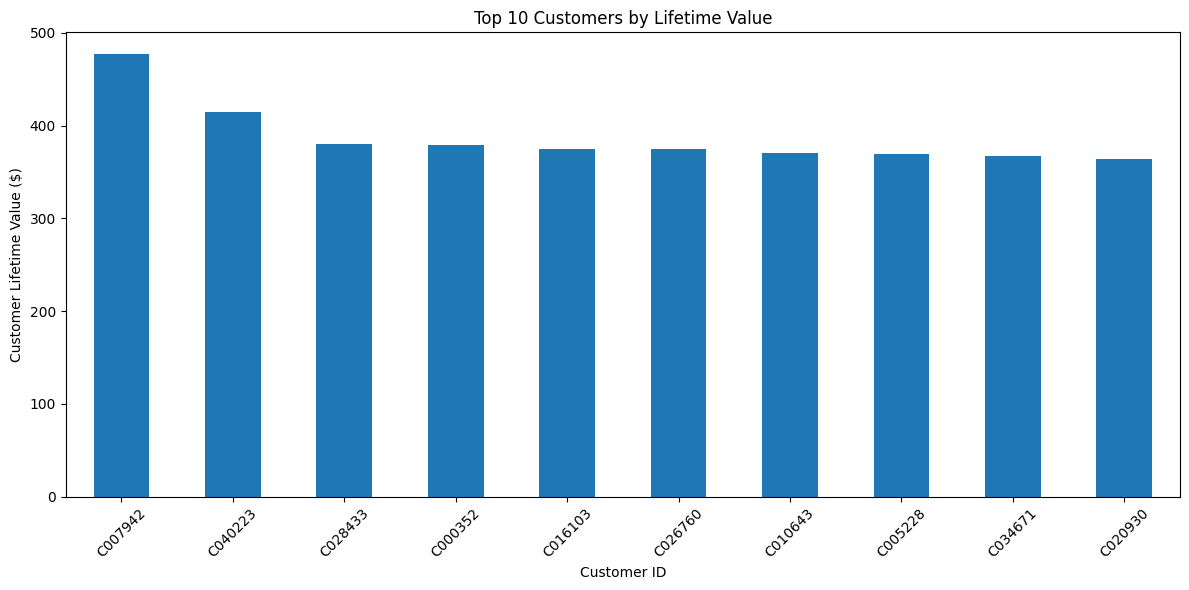

In [118]:
# Top 10 customers by Customer Lifetime Value

top_clv = customer_clv.head(10).copy()

top_clv["customer_id"] = top_clv["customer_id"].astype(str)

top_clv.plot(
    x="customer_id",
    y="customer_lifetime_value",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)

plt.title("Top 10 Customers by Lifetime Value")
plt.xlabel("Customer ID")
plt.ylabel("Customer Lifetime Value ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

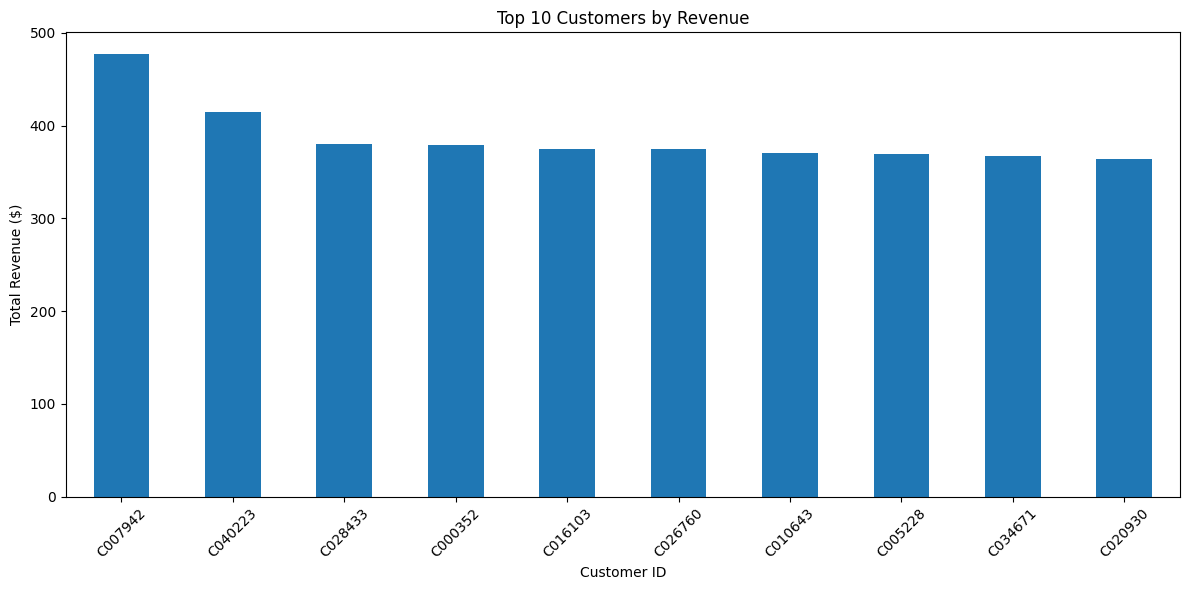

In [119]:
# Top 10 customers by revenue ranking

top_revenue_customers = customer_revenue_ranking.head(10).copy()

top_revenue_customers["customer_id"] = (
    top_revenue_customers["customer_id"].astype(str)
)

top_revenue_customers.plot(
    x="customer_id",
    y="total_revenue",
    kind="bar",
    legend=False,
    figsize=(12, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [121]:
# StreamSphere business insights summary

print("========== STREAMSPHERE BUSINESS INSIGHTS ==========\n")

print(f"1. Customer Base: {total_customers:,} customers")
print(f"2. Total Subscriptions: {total_subscriptions:,}")
print(f"3. Active Subscriptions: {active_subscriptions:,}")
print(f"4. Cancelled Subscriptions: {cancelled_subscriptions:,}")
print(f"5. Overall Churn Rate: {churn_rate:.2f}%")
print(f"6. Successful Revenue: ${successful_revenue:,.2f}")
print(f"7. Average Transaction Value: ${average_transaction:,.2f}")

print("\n========== TOP PERFORMERS ==========\n")

top_country = revenue_by_country.iloc[0]
top_plan = revenue_by_plan.iloc[0]
top_channel = channel_customers.iloc[0]
top_campaign = campaign_conversion.iloc[0]
top_event = event_type_distribution.iloc[0]

print(
    f"Top Revenue Country: {top_country['country']} "
    f"(${top_country['total_revenue']:,.2f})"
)

print(
    f"Top Revenue Plan: {top_plan['plan_name']} "
    f"(${top_plan['total_revenue']:,.2f})"
)

print(
    f"Top Acquisition Channel: {top_channel['acquisition_channel']} "
    f"({top_channel['customer_count']:,} customers)"
)

print(
    f"Top Campaign by Conversion Rate: {top_campaign['campaign_name']} "
    f"({top_campaign['conversion_rate']:.2f}%)"
)

print(
    f"Most Common User Event: {top_event['event_type']} "
    f"({top_event['event_count']:,} events)"
)

print("\n========== ANALYSIS COMPLETE ==========")

========== STREAMSPHERE BUSINESS INSIGHTS ==========

1. Customer Base: 50,000 customers
2. Total Subscriptions: 60,000
3. Active Subscriptions: 39,086
4. Cancelled Subscriptions: 20,914
5. Overall Churn Rate: 34.86%
6. Successful Revenue: $2,264,919.51
7. Average Transaction Value: $12.05

========== TOP PERFORMERS ==========

Top Revenue Country: United States ($663,043.58)
Top Revenue Plan: Standard ($1,093,796.97)
Top Acquisition Channel: Instagram (10,057 customers)
Top Campaign by Conversion Rate: Email Re-engagement (20.00%)
Most Common User Event: Play (225,189 events)

========== ANALYSIS COMPLETE ==========
